Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [250]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [251]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [265]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1997].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.6

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

In [253]:
1+(12-6)/6

2.0

In [254]:
def traitement_bis(df):
    # 1. On définit notre seuil de référence à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002]
    
    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['total_equipements']
    df['seuil'] = df['codecommune'].map(mapping_seuil)
    
    # 3. Calcul du pourcentage restant par rapport à 2002
    # La division directe est plus propre. On multiplie par 100 pour un format lisible.
    df['traitement'] = ((df['total_equipements'] == 0)&(df['total_equipements'] < df['seuil'])&(df['Annee'] >2002)).astype(int)

    df['traitement'] = df['traitement'].replace([float('inf')], 0)
    df['traitement'] = df['traitement'].fillna(0)

    
    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])
    
    return df

## Calcul du traitement

### RNP

In [255]:
df_rnp = traitement(df_rnp)

### RP

In [266]:
df_rp = traitement(df_rp)

### UI

In [257]:
df_ui = traitement(df_ui)

### UD

In [258]:
df_ud = traitement(df_ud)

## DID

In [ ]:
#df_rnp[(df_rnp['traitement']==1)&(df_rnp['Annee']==2022)]

KeyError: 'traitement'

Definition du modele

In [260]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [1995, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_pres', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_pres'] = df_pres['vote_RN_pres'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_pres',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000074 0.000695 -0.001289 0.001437 35712.0     5058.0 35712.0       5058.0
            Effect_2  0.002906 0.000907  0.001129 0.004683 27032.0     4588.0 27032.0       4588.0
            Effect_3  0.005638 0.001214  0.003259 0.008018 19730.0     4034.0 19730.0       4034.0
            Effect_4  0.008605 0.001617  0.005436 0.011774 12978.0     3117.0 12978.0       3117.0
            Effect_5  0.009912 0.002318  0.005369 0.014456  6234.0     1650.0  6234.0       1650.0
Average_Total_Effect  0.004317 0.000934  0.002485 0.006148 49119.0    18447.0 49119.0      18447.0
           Placebo_1  0.000606 0.000816 -0.000992 0.002205 25791.0     3364.0 25791.0       3364.0
           Placebo_2 -0.000304 0.001436 -0.003119 0.002511 11299.0     1447.0 11299.0       1447.0
Test of joint nullity of the effects: p-val

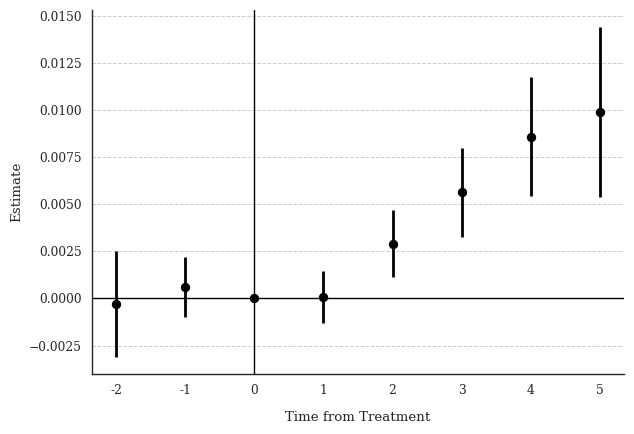

In [268]:
DID(df_rnp)

In [ ]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = 0.006144 
se_placebo =   0.005294

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : 1.161
P-value du Placebo : 0.246


### RP

In [ ]:
df_rnp['codecommune'][(df_rnp['traitée']==1)&(df_rnp['Annee']<2002)].unique()

<ArrowStringArray>
['01007', '01012', '01017', '01028', '01037', '01066', '01067', '01118',
 '01133', '01191',
 ...
 '89391', '89398', '89407', '89412', '89423', '89433', '89462', '89485',
 '90014', '90078']
Length: 2546, dtype: str

In [ ]:
df_rp['codecommune'][(df_rp['traitée']==1)&(df_rp['Annee']<2002)].unique()

<ArrowStringArray>
['01011', '01029', '01045', '01054', '01085', '01106', '01115', '01130',
 '01147', '01151',
 ...
 '91435', '95002', '95040', '95287', '95365', '95379', '95459', '95483',
 '95527', '95584']
Length: 1496, dtype: str

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001088 0.000688 -0.000260 0.002436 36134.0     4563.0 36134.0       4563.0
            Effect_2  0.002420 0.000892  0.000672 0.004168 27494.0     4148.0 27494.0       4148.0
            Effect_3  0.003627 0.001187  0.001300 0.005954 20072.0     3607.0 20072.0       3607.0
            Effect_4  0.004713 0.001633  0.001513 0.007914 13191.0     2742.0 13191.0       2742.0
            Effect_5  0.003780 0.002327 -0.000782 0.008342  6362.0     1385.0  6362.0       1385.0
Average_Total_Effect  0.002812 0.000947  0.000956 0.004668 48023.0    16445.0 48023.0      16445.0
           Placebo_1  0.000766 0.000800 -0.000802 0.002334 26497.0     3157.0 26497.0       3157.0
           Placebo_2 -0.001334 0.001398 -0.004074 0.001405 11842.0     1395.0 11842.0       1395.0
Test of joint nullity of the effects: p-val

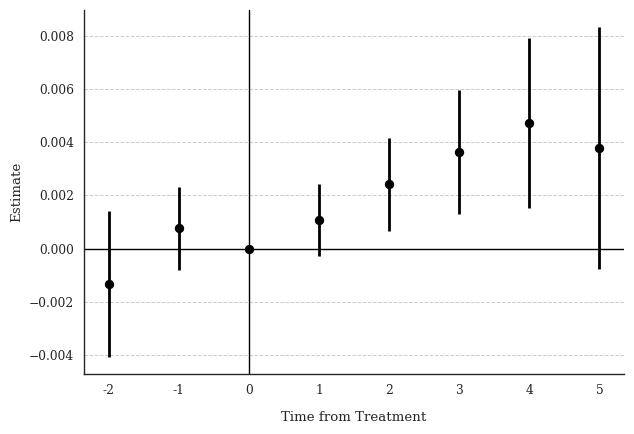

In [269]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.002707 0.000883  0.000977  0.004437 10903.0     1540.0 10903.0       1540.0
            Effect_2  0.007490 0.001299  0.004944  0.010036  8197.0     1431.0  8197.0       1431.0
            Effect_3  0.014222 0.001931  0.010438  0.018007  5971.0     1256.0  5971.0       1256.0
            Effect_4  0.017607 0.002702  0.012312  0.022902  3919.0      929.0  3919.0        929.0
            Effect_5  0.009904 0.004081  0.001904  0.017903  1825.0      384.0  1825.0        384.0
Average_Total_Effect  0.009551 0.001489  0.006631  0.012470 14904.0     5540.0 14904.0       5540.0
           Placebo_1 -0.001523 0.001001 -0.003486  0.000440  7921.0     1156.0  7921.0       1156.0
           Placebo_2 -0.006491 0.001920 -0.010254 -0.002729  3490.0      500.0  3490.0        500.0
Test of joint nullity of the effec

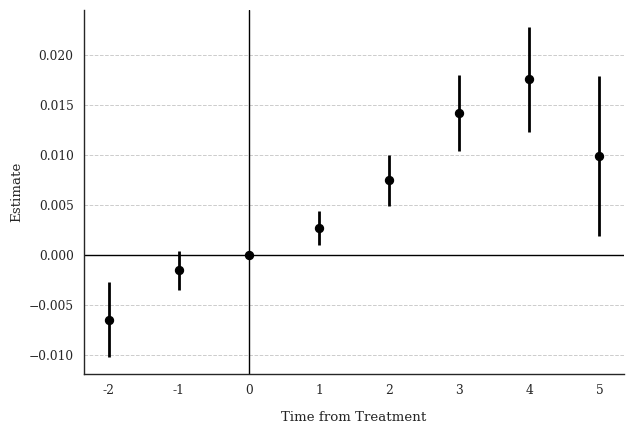

In [270]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.005705 0.001811  0.002155  0.009255 2778.0      213.0 2778.0        213.0
            Effect_2  0.015905 0.003111  0.009807  0.022003 2140.0      204.0 2140.0        204.0
            Effect_3  0.022284 0.004631  0.013207  0.031361 1566.0      174.0 1566.0        174.0
            Effect_4  0.019306 0.005923  0.007697  0.030914 1022.0      117.0 1022.0        117.0
            Effect_5  0.026042 0.012329  0.001878  0.050206  481.0       33.0  481.0         33.0
Average_Total_Effect  0.015459 0.003202  0.009184  0.021735 3306.0      741.0 3306.0        741.0
           Placebo_1 -0.003542 0.001829 -0.007127  0.000044 2116.0      180.0 2116.0        180.0
           Placebo_2 -0.011428 0.003751 -0.018779 -0.004077  992.0       87.0  992.0         87.0
Test of joint nullity of the effects: p-value = 0.00

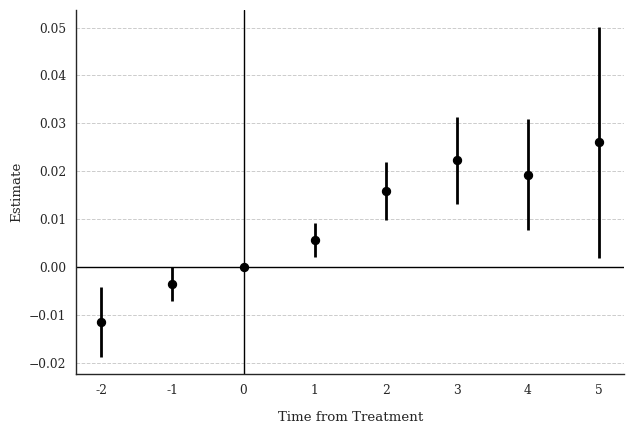

In [271]:
DID(df_ud)